In [ ]:
pip install pandas --quiet

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/Datasets /Nasa_kepler_exoplanet_data.csv"
df1 = pd.read_csv(file_path)
df1.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 

In [ ]:
print(f"Number of Rows: {df1.shape[0]}")
print(f"Number of Columns: {df1.shape[1]}")

Number of Rows: 9564
Number of Columns: 50


# Explanation of the Dataset

The Keplar Telescope is aimed at many stars and records their brightness continously and very precisely. If the brightness dims then it is concluded that something passed infront of the star. <br>
If brightness dims regularly then the Keplar registers it as a `Keplar Object of Interest` (`KOI`). <br>
The dataset have 50 columns as it has gone through ML models and many of those columns corresponds to that. The description of the columns are in the following link:
https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html

We can divide the columns into 5 different categories then we can seperate or drop those which are not in need. The five categories are as follows:

<br>

1.  The target column: `koi_disposition`: The label whether the KOI is:
    * <u>CONFIRMED:</u> Keplar team has validated it as an exoplanet.
    * <u>CANDIDATE:</u> Looks like a planet but not yet confirmed.
    * <u>FALSE POSITIVE:</u>  The signal is caused by something else.<br>
    
    Although the target variable is not binary we will change this in EDA part of the modelling. <br>
<br>

2.  The X vairable columns:
    * <u>**Transit + signal features:**</u> Transit properties are the measurable characteristics of the brightness dip that occurs when a planet (or another object) passes in front of its star and blocks part of the star’s light. These properties describe how often, how deep, and how long the dimming event is, and they are essential for distinguishing real planets from false positives. <br>
    Following are some of the
      - `koi_period`: How frequently the dip happens.
      - `koi_duration`: How long the dip lasts.
      - `koi_depth`: How much the star's brightness decreases.
      - `koi_ror`: The planet radius divided by the stellar radius.
      - `koi_prad`: The radius of the planet. Product of planet to star (ror) ratio and the stellar radius.
      - `koi_impact`: "Impact parameter" How central the transit is.
      - `koi_teq`: Approximation for the temperature of the planet.
      - `koi_insol`: "Isolation flux" How much solar energy strikes the planet relative to the earth.

    * <u>**Stellar Parameters:**</u> Parameters related to the target star. Sometimes the type of star determine if the signal is real or a glitch. It includes:
      - `koi_steff`: Stellar effective temperature of the star in Kelvins.
      - `koi_slogg`: Star surface gravity in base 10 log.
      - `koi_srad`: Star radius.




In [ ]:
# we can just type out all the columns we wanted to add so the rest of them will be deleted.
columns_to_keep = [
    'koi_disposition',
    'koi_period',
    'koi_duration',
    'koi_depth',
    'koi_prad',
    'koi_impact',
    'koi_teq',
    'koi_insol',
    'koi_steff',
    'koi_slogg',
    'koi_srad',
    'koi_model_snr'
]
df3 = df1[columns_to_keep]
df3.head()

,koi_disposition,koi_period,koi_duration,koi_depth,koi_prad,koi_impact,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,koi_model_snr
0,CONFIRMED,9.488036,2.95750,615.8,2.26,0.146,793.0,93.59,5455.0,4.467,0.927,35.8
1,CONFIRMED,54.418383,4.50700,874.8,2.83,0.586,443.0,9.11,5455.0,4.467,0.927,25.8
2,FALSE POSITIVE,19.899140,1.78220,10829.0,14.60,0.969,638.0,39.30,5853.0,4.544,0.868,76.3
3,FALSE POSITIVE,1.736952,2.40641,8079.2,33.46,1.276,1395.0,891.96,5805.0,4.564,0.791,505.6
4,CONFIRMED,2.525592,1.65450,603.3,2.75,0.701,1406.0,926.16,6031.0,4.438,1.046,40.9


Now we have to convert the target column into binary so that our model can read it.

In [ ]:
df3['koi_disposition_binary'] = df3['koi_disposition'].apply(lambda x: 1 if x == 'CONFIRMED' else 0)
df3.head()

/tmp/ipython-input-2919162517.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['koi_disposition_binary'] = df3['koi_disposition'].apply(lambda x: 1 if x == 'CONFIRMED' else 0)


,koi_disposition,koi_period,koi_duration,koi_depth,koi_prad,koi_impact,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,koi_model_snr,koi_disposition_binary
0,CONFIRMED,9.488036,2.95750,615.8,2.26,0.146,793.0,93.59,5455.0,4.467,0.927,35.8,1
1,CONFIRMED,54.418383,4.50700,874.8,2.83,0.586,443.0,9.11,5455.0,4.467,0.927,25.8,1
2,FALSE POSITIVE,19.899140,1.78220,10829.0,14.60,0.969,638.0,39.30,5853.0,4.544,0.868,76.3,0
3,FALSE POSITIVE,1.736952,2.40641,8079.2,33.46,1.276,1395.0,891.96,5805.0,4.564,0.791,505.6,0
4,CONFIRMED,2.525592,1.65450,603.3,2.75,0.701,1406.0,926.16,6031.0,4.438,1.046,40.9,1


In [ ]:
df3['koi_disposition_binary'].value_counts()

,count
koi_disposition_binary,
0,7271
1,2293


In [ ]:
df3['koi_disposition'].value_counts()
df3.info()
df3['koi_depth'].isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   koi_disposition         9564 non-null   object 
 1   koi_period              9564 non-null   float64
 2   koi_duration            9564 non-null   float64
 3   koi_depth               9201 non-null   float64
 4   koi_prad                9201 non-null   float64
 5   koi_impact              9201 non-null   float64
 6   koi_teq                 9201 non-null   float64
 7   koi_insol               9243 non-null   float64
 8   koi_steff               9201 non-null   float64
 9   koi_slogg               9201 non-null   float64
 10  koi_srad                9201 non-null   float64
 11  koi_model_snr           9201 non-null   float64
 12  koi_disposition_binary  9564 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 971.5+ KB


np.int64(363)

In [ ]:
print(df3.isna().sum())

koi_disposition             0
koi_period                  0
koi_duration                0
koi_depth                 363
koi_prad                  363
koi_impact                363
koi_teq                   363
koi_insol                 321
koi_steff                 363
koi_slogg                 363
koi_srad                  363
koi_model_snr             363
koi_disposition_binary      0
dtype: int64


In [ ]:
# Drop the rows which have any null values in it
df4 = df3.dropna()
df4

,koi_disposition,koi_period,koi_duration,koi_depth,koi_prad,koi_impact,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,koi_model_snr,koi_disposition_binary
0,CONFIRMED,9.488036,2.95750,615.8,2.26,0.146,793.0,93.59,5455.0,4.467,0.927,35.8,1
1,CONFIRMED,54.418383,4.50700,874.8,2.83,0.586,443.0,9.11,5455.0,4.467,0.927,25.8,1
2,FALSE POSITIVE,19.899140,1.78220,10829.0,14.60,0.969,638.0,39.30,5853.0,4.544,0.868,76.3,0
3,FALSE POSITIVE,1.736952,2.40641,8079.2,33.46,1.276,1395.0,891.96,5805.0,4.564,0.791,505.6,0
4,CONFIRMED,2.525592,1.65450,603.3,2.75,0.701,1406.0,926.16,6031.0,4.438,1.046,40.9,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,FALSE POSITIVE,8.589871,4.80600,87.7,1.11,0.765,929.0,176.40,5638.0,4.296,1.088,8.4,0
9560,FALSE POSITIVE,0.527699,3.22210,1579.2,29.35,1.252,2088.0,4500.53,5638.0,4.529,0.903,453.3,0
9561,CANDIDATE,1.739849,3.11400,48.5,0.72,0.043,1608.0,1585.81,6119.0,4.444,1.031,10.6,0
9562,FALSE POSITIVE,0.681402,0.86500,103.6,1.07,0.147,2218.0,5713.41,6173.0,4.447,1.041,12.3,0


In [ ]:
# No more null values in the new dataframe
print(df4.isna().sum())

koi_disposition           0
koi_period                0
koi_duration              0
koi_depth                 0
koi_prad                  0
koi_impact                0
koi_teq                   0
koi_insol                 0
koi_steff                 0
koi_slogg                 0
koi_srad                  0
koi_model_snr             0
koi_disposition_binary    0
dtype: int64


## Defining X and Y variable column
Now define X and Y variable dataframe.

In [ ]:
Y = df4['koi_disposition_binary']
X = df4.drop(columns=['koi_disposition_binary', 'koi_disposition'])
print("X Shape: ",X.shape)
print("y Shape: ",Y.shape)

X Shape:  (9201, 11)
y Shape:  (9201,)


## Train Test Split and scaling
Now we split our data into train and test


In [ ]:
X.describe()

,koi_period,koi_duration,koi_depth,koi_prad,koi_impact,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,koi_model_snr
count,9201.000000,9201.000000,9.201000e+03,9201.000000,9201.000000,9201.000000,9.201000e+03,9201.000000,9201.000000,9201.000000,9201.000000
mean,74.307951,5.654692,2.379134e+04,102.891778,0.735105,1085.385828,7.716611e+03,5706.823280,4.310157,1.728712,259.895001
std,1360.538847,6.499703,8.224268e+04,3077.639126,3.348832,856.351161,1.595455e+05,796.857947,0.432606,6.127185,795.806615
min,0.241843,0.052000,0.000000e+00,0.080000,0.000000,25.000000,0.000000e+00,2661.000000,0.047000,0.109000,0.000000
25%,2.682768,2.453600,1.599000e+02,1.400000,0.197000,539.000000,2.001000e+01,5310.000000,4.218000,0.829000,12.000000
50%,9.296746,3.824330,4.211000e+02,2.390000,0.537000,878.000000,1.407300e+02,5767.000000,4.438000,1.000000,23.000000
75%,36.856776,6.289000,1.473400e+03,14.930000,0.889000,1379.000000,8.535000e+02,6112.000000,4.543000,1.345000,78.000000
max,129995.778400,138.540000,1.541400e+06,200346.000000,100.806000,14667.000000,1.094755e+07,15896.000000,5.364000,229.908000,9054.700000


In [ ]:
pip install scikit-learn --quiet

The model must not learn anything from the test data.
The test set must remain completely unseen until final evaluation.

When we scale:

✔ We fit on the training data
→ This learns the mean and standard deviation only from training.

✔ We then transform the test data
→ This applies the same exact scaling that was learned from training.

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# SPLIT THE DATA INTO TEST AND TRAIN SETS
# We use stratify when there are imbalance classes in y column.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state = 42, stratify= Y )

# FIT SCALAR *ONLY* ON TRAINING DATA TO PREVENT LEAKAGE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(len(X_train_scaled))
print(len(X_test_scaled))

6900
2301


## TRAINING MODELS AND GETTING RESULTS
Now we will train our models and test them on the test data set and then calculate their accuracies.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---- MODEL 1: Logistic Regression ----
log_reg = LogisticRegression(max_iter= 1000, random_state = 42)   # Initiate the model
log_reg.fit(X_train_scaled, Y_train)                              # Train the model
Y_pred_log_reg = log_reg.predict(X_test_scaled)                   # Predict the Y
acc_log_reg = accuracy_score(Y_test, Y_pred_log_reg)              # Calculate the accuracy
precisionLR = precision_score(Y_test, Y_pred_log_reg)             # Precision Score
recallLR = recall_score(Y_test, Y_pred_log_reg)                   # Recall Score
f1LR = f1_score(Y_test, Y_pred_log_reg)                           # F1 Score
print(f"Logistic Regression Accuracy: {acc_log_reg:.4f}")
print(f"Logistic Regression Precision: {precisionLR:.4f}")
print(f"Logistic Regression Recall: {recallLR:.4f}")
print(f"Logistic Regression F1 Score: {f1LR:.4f}")

# ---- MODEL 2: Random Forest ----
rf = RandomForestClassifier(n_estimators = 100, random_state = 42) # n_estimator=100 means we use 100 different decision trees
rf.fit(X_train_scaled, Y_train)                                   # Train the model
Y_pred_rf = rf.predict(X_test_scaled)                             # Predict the Y
acc_rf = accuracy_score(Y_test, Y_pred_rf)                        # Calculate the accuracy
precisionRF = precision_score(Y_test, Y_pred_rf)                  # Precision Score
recallRF = recall_score(Y_test, Y_pred_rf)                        # Recall Score
f1RF = f1_score(Y_test, Y_pred_rf)                                # F1 Score
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(f"Random Forest Precision: {precisionRF:.4f}")
print(f"Random Forest Recall: {recallRF:.4f}")
print(f"Random Forest F1 Score: {f1RF:.4f}")

# ---- MODEL 3: Support Vector Machine ----
svm = SVC(kernel='rbf', random_state = 42)                        # rbf Kernel is Gaussain Kernel
svm.fit(X_train_scaled, Y_train)                                  # Train the model
Y_pred_svm = svm.predict(X_test_scaled)                           # Predict the Y
acc_svm = accuracy_score(Y_test, Y_pred_svm)                      # Calculate the accuracy
precisionSVM = precision_score(Y_test, Y_pred_svm)                # Precision Score
recallSVM = recall_score(Y_test, Y_pred_svm)                      # Recall Score
f1SVM = f1_score(Y_test, Y_pred_svm)                              # F1 Score
print(f"Support Vector Machine Accuracy: {acc_svm:.4f}")
print(f"Support Vector Machine Precision: {precisionSVM:.4f}")
print(f"Support Vector Machine Recall: {recallSVM:.4f}")
print(f"Support Vector Machine F1 Score: {f1SVM:.4f}")

Logistic Regression Accuracy: 0.7523
Logistic Regression Precision: 0.5062
Logistic Regression Recall: 0.2147
Logistic Regression F1 Score: 0.3015
Random Forest Accuracy: 0.8709
Random Forest Precision: 0.7575
Random Forest Recall: 0.7086
Random Forest F1 Score: 0.7322
Support Vector Machine Accuracy: 0.7579
Support Vector Machine Precision: 0.6176
Support Vector Machine Recall: 0.0733
Support Vector Machine F1 Score: 0.1310


As we can see the Random Forest have the highest accuracy as it can handle complex non linear data very easily as compared to other models

## METRICS AND RESULTS

In [ ]:
pip install seaborn matplotlib --quiet

### CONFUSION MATRIX

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1728
           1       0.76      0.71      0.73       573

    accuracy                           0.87      2301
   macro avg       0.83      0.82      0.82      2301
weighted avg       0.87      0.87      0.87      2301



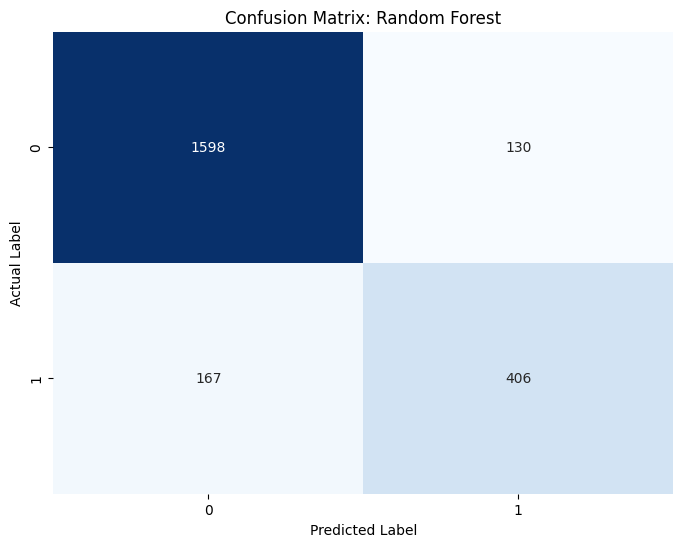

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Generate confusion matrix for the BEST model i.e. Random Forest
cm = confusion_matrix(Y_test, Y_pred_rf)

# Plotting the Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot= True, fmt='d', cmap='Blues', cbar= False)
plt.title("Confusion Matrix: Random Forest")
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show

# Print Classification Report
print("Classification Report (Random Forest):")
print(classification_report(Y_test, Y_pred_rf))

### FEATURE IMPORTANCE

/tmp/ipython-input-887874827.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


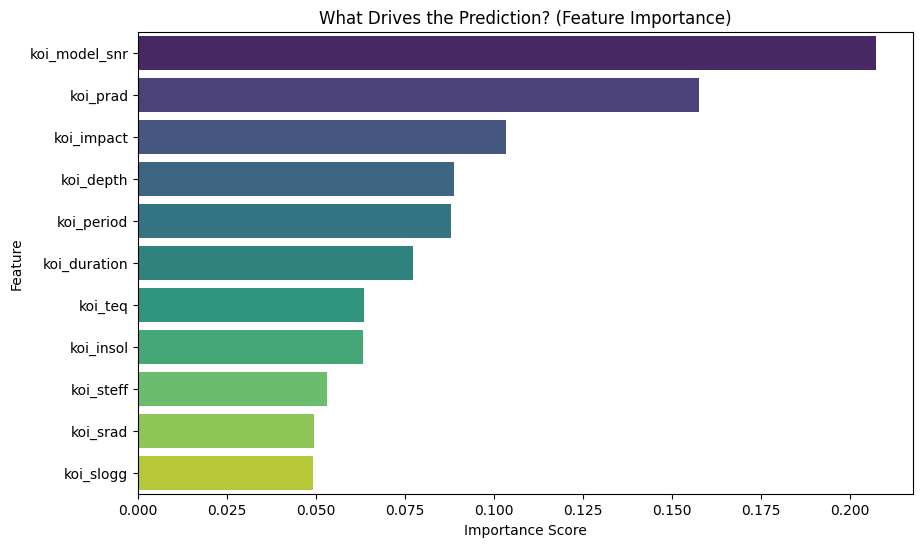

In [ ]:
# 1. Get feature importance numbers from the model
import pandas as pd
import numpy as np

importances = rf.feature_importances_
feature_names = X.columns

# 2. Organize them into a DataFrame
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# 3. Plot the Top 10 Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('What Drives the Prediction? (Feature Importance)')
plt.xlabel('Importance Score')
plt.show()

### ROC CURVE & AUC VALUE

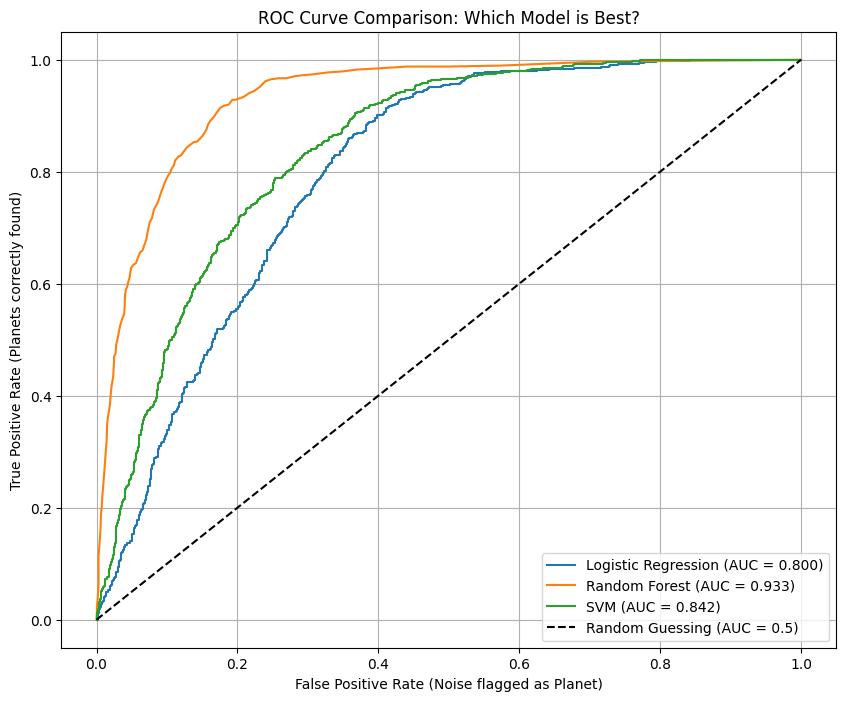

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# --- 1. Logistic Regression ---
# We use predict_proba to get the probability score (Column 1 is the "Positive" class)
y_prob_logreg = log_reg.predict_proba(X_test_scaled)[:, 1]   #Y_scores
fpr_log, tpr_log, _ = roc_curve(Y_test, y_prob_logreg)
auc_log = auc(fpr_log, tpr_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')

# --- 2. Random Forest ---
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]            #Y_Scores
fpr_rf, tpr_rf, _ = roc_curve(Y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

# --- 3. SVM ---
# SVM (default) doesn't give probabilities, it gives "Decision Function" scores
y_score_svm = svm.decision_function(X_test_scaled)           #Y_scores
fpr_svm, tpr_svm, _ = roc_curve(Y_test, y_score_svm)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')

# --- Plot Formatting ---
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')
plt.xlabel('False Positive Rate (Noise flagged as Planet)')
plt.ylabel('True Positive Rate (Planets correctly found)')
plt.title('ROC Curve Comparison: Which Model is Best?')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve

# 1. Get the probability scores from your Random Forest model
y_probs = rf.predict_proba(X_test_scaled)[:, 1]

# 2. Generate the ROC curve values
fpr, tpr, thresholds = roc_curve(Y_test, y_probs)

# 3. Calculate Youden's J statistic for every point
# Formula: J = TPR - FPR
J = tpr - fpr

# 4. Find the index where J is the highest
ix = np.argmax(J)

# 5. Extract the best threshold and its metrics
best_thresh = thresholds[ix]

print(f"--- Optimal Threshold (ROC Method) ---")
print(f"Best Threshold: {best_thresh:.4f}")
print(f"TPR (Recall) at this point: {tpr[ix]:.4f}")
print(f"FPR (Noise) at this point:  {fpr[ix]:.4f}")

--- Optimal Threshold (ROC Method) ---
Best Threshold: 0.2400
TPR (Recall) at this point: 0.9145
FPR (Noise) at this point:  0.1759


In [ ]:
# PRECISION RECALL CURVE
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

#fig, axs = plt.subplots(3, 1, figsize=(10,16))

# PR Curve: LOGISTIC REGRESSION
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(Y_test, y_prob_logreg)
#axs[0].plot(recall_lr,precision_lr, label = "Logistic Regression PR Curve")
#axs[0].set_title("Logistic Regression PR Curve")

# PR Curve: RANDOM FOREST
precesion_rf, recall_rf, thresholds_rf = precision_recall_curve(Y_test, y_prob_rf)
#axs[1].plot(recall_rf,precesion_rf, label = "Random Forest PR Curve")
#axs[1].set_title("Random Forest PR Curve")

# PR Curve: SUPPORT VECTOR MACHINE
precesion_svm, recall_svm, thresholds_svm = precision_recall_curve(Y_test, y_score_svm)
#axs[2].plot(recall_svm,precesion_svm, label = "SVM PR Curve")
#axs[2].set_title("SVM PR Curve")

#print(f"LOGISTIC REGRESSION METRICS: \n Precision: {precision_lr} \n Recall: {recall_lr}")

### PRECISION RECALL CURVE

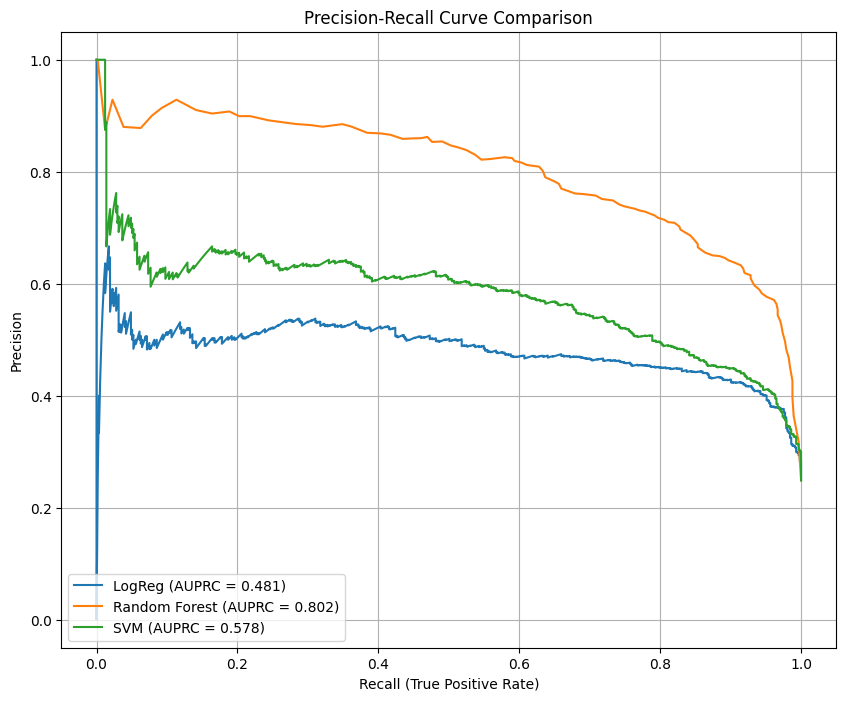

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc # You'll need this to calculate the Area Under the PR Curve (AUPRC)

plt.figure(figsize=(10, 8))
plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision')

# 1. LOGISTIC REGRESSION
precision_lr, recall_lr, _ = precision_recall_curve(Y_test, y_prob_logreg)
# Calculate AUPRC for the label
auprc_lr = auc(recall_lr, precision_lr)
plt.plot(recall_lr, precision_lr, label=f'LogReg (AUPRC = {auprc_lr:.3f})')

# 2. RANDOM FOREST
precision_rf, recall_rf, _ = precision_recall_curve(Y_test, y_prob_rf)
auprc_rf = auc(recall_rf, precision_rf)
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AUPRC = {auprc_rf:.3f})')

# 3. SUPPORT VECTOR MACHINE
precision_svm, recall_svm, _ = precision_recall_curve(Y_test, y_score_svm)
auprc_svm = auc(recall_svm, precision_svm)
plt.plot(recall_svm, precision_svm, label=f'SVM (AUPRC = {auprc_svm:.3f})')

plt.legend(loc='lower left')
plt.grid(True)
plt.show()
